In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib

# -------------------------
# 1️⃣ قراءة الداتاسيت
# -------------------------
df = pd.read_csv(r"FireSpread\FDS6\bin\final_training_data.csv")

print("Dataset shape:", df.shape)
print(df.head())

# -------------------------
# 2️⃣ تحديد المدخلات والمخرجات
# -------------------------
X = df[["fire_row", "fire_col", "time", "cell_row", "cell_col"]]
y = df["risk"]

# -------------------------
# 3️⃣ تقسيم البيانات
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# 4️⃣ إنشاء المودل
# -------------------------
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8
)

# -------------------------
# 5️⃣ التدريب
# -------------------------
print("Training model...")
model.fit(X_train, y_train)

# -------------------------
# 6️⃣ التقييم
# -------------------------
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

# -------------------------
# 7️⃣ حفظ المودل
# -------------------------
joblib.dump(model, "fire_risk_xgb.pkl")

print("✅ Model saved successfully")

Dataset shape: (2028576, 6)
   fire_row  fire_col  time  cell_row  cell_col        risk
0         1         4     0         1         3   20.000000
1         1         4     1         1         3   20.000000
2         1         4     2         1         3   20.006811
3         1         4     3         1         3  184.442270
4         1         4     4         1         3  211.484650
Training model...
MSE: 686.2969155388652
✅ Model saved successfully


In [6]:
joblib.dump(X_train.columns.tolist(), "model_features.pkl")

['model_features.pkl']


📊 Evaluation:
MSE : 686.2969155388652
RMSE: 26.197269238202388
MAE : 13.53234045922509
R2  : 0.8952772351533478


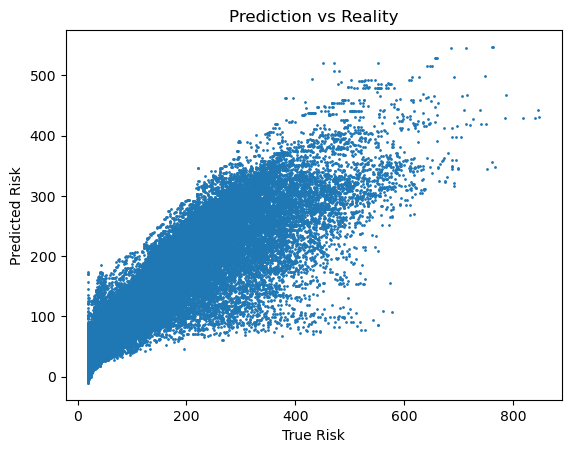

In [7]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📊 Evaluation:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

# =====================================================
# 9️⃣ رسم النتائج
# =====================================================

# مقارنة القيم الحقيقية مع المتوقعة
plt.figure()
plt.scatter(y_test, y_pred, s=1)
plt.xlabel("True Risk")
plt.ylabel("Predicted Risk")
plt.title("Prediction vs Reality")
plt.show()


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [5]:
model = joblib.load("fire_risk_xgb.pkl")
columns = joblib.load("model_features.pkl")
columns

['fire_row', 'fire_col', 'time', 'cell_row', 'cell_col']

In [30]:
import pandas as pd

data = pd.DataFrame({
    "fire_row":[3],
    "fire_col":[4],
    "time":[37],
    "cell_row":[3],
    "cell_col":[9]
})


In [31]:
prediction = model.predict(data)

print("Prediction:", prediction)

Prediction: [38.952896]
